**load the final feature dataset and frozen split**

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FEATURES_PATH = (
    PROJECT_ROOT
    / "data"
    / "features"
    / "sleep_edf_features.csv"
)

df = pd.read_csv(
    FEATURES_PATH
)

split_df = pd.read_csv(
    PROJECT_ROOT
    / "data"
    / "features"
    / "subject_split.csv"
)

df = df.merge(
    split_df,
    on="subject_id",
    how="inner",
    validate="many_to_one",
)

print(
    "Dataset:",
    df.shape
)

print(
    "Subjects:",
    df["subject_id"].nunique()
)

Dataset: (457577, 17)
Subjects: 197


**Recreate the normalized data**

In [2]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parent.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing.normalization import (
    SleepFeatureScaler,
)

from src.preprocessing.sequences import (
    find_contiguous_runs,
    build_sequences_from_dataframe,
    encode_sleep_stage_labels,
)

FEATURES_PATH = (
    PROJECT_ROOT
    / "data"
    / "features"
    / "sleep_edf_features.csv"
)

SPLIT_PATH = (
    PROJECT_ROOT
    / "data"
    / "features"
    / "subject_split.csv"
)

df = pd.read_csv(FEATURES_PATH)

split_df = pd.read_csv(SPLIT_PATH)

df_with_split = df.merge(
    split_df,
    on="subject_id",
    how="inner",
    validate="many_to_one",
)

train_df = (
    df_with_split[
        df_with_split["split"] == "train"
    ]
    .sort_values(
        ["subject_id", "start_time"]
    )
    .reset_index(drop=True)
)

val_df = (
    df_with_split[
        df_with_split["split"] == "val"
    ]
    .sort_values(
        ["subject_id", "start_time"]
    )
    .reset_index(drop=True)
)

test_df = (
    df_with_split[
        df_with_split["split"] == "test"
    ]
    .sort_values(
        ["subject_id", "start_time"]
    )
    .reset_index(drop=True)
)

feature_scaler = SleepFeatureScaler()

X_train_scaled = (
    feature_scaler.fit_transform(
        train_df
    )
)

X_val_scaled = (
    feature_scaler.transform(
        val_df
    )
)

X_test_scaled = (
    feature_scaler.transform(
        test_df
    )
)

print(
    X_train_scaled.shape,
    X_val_scaled.shape,
    X_test_scaled.shape,
)

(319628, 10) (69602, 10) (68347, 10)


**Calculate sequence-target counts per subject**

In [3]:
from src.preprocessing.sequences import (
    find_contiguous_runs,
)

SEQUENCE_LENGTH = 10

stage_order = [
    "W",
    "N1",
    "N2",
    "N3",
    "REM",
]

subject_sequence_counts = []

for subject_id, subject_df in (
    df.groupby("subject_id", sort=False)
):

    subject_df = (
        subject_df
        .sort_values("start_time")
        .reset_index(drop=True)
    )

    runs = find_contiguous_runs(
        subject_df
    )

    counts = {
        stage: 0
        for stage in stage_order
    }

    for run in runs:

        if len(run) < SEQUENCE_LENGTH:
            continue

        target_stages = (
            run["target_stage"]
            .iloc[
                SEQUENCE_LENGTH - 1:
            ]
        )

        counts.update({
            stage: counts[stage]
            + int(
                (target_stages == stage).sum()
            )
            for stage in stage_order
        })

    subject_sequence_counts.append(
        {
            "subject_id": subject_id,
            **counts,
        }
    )

subject_sequence_counts = pd.DataFrame(
    subject_sequence_counts
).set_index("subject_id")

print(
    "Subject sequence-target matrix:"
)

display(
    subject_sequence_counts.head(10)
)

Subject sequence-target matrix:


,W,N1,N2,N3,REM
subject_id,,,,,
SC4001,1988,58,250,220,125
SC4002,1876,59,373,288,215
SC4011,1847,109,562,105,170
SC4012,1815,92,660,96,176
SC4021,1898,94,545,95,163
SC4022,1862,179,399,119,178
SC4031,1999,61,485,57,209
SC4032,1948,45,400,131,199
SC4041,1525,164,620,53,189


**Compare the current split using sequence targets**

In [4]:
current_sequence_split = (
    subject_sequence_counts
    .join( # type: ignore
        split_df.set_index(
            "subject_id"
        )
    )
)

sequence_split_counts = (
    current_sequence_split
    .groupby("split")[
        stage_order
    ]
    .sum()
)

sequence_split_percentages = (
    sequence_split_counts.div(
        sequence_split_counts.sum(axis=1),
        axis=0,
    )
    * 100
)

print("Sequence target counts:")
display(
    sequence_split_counts
)

print(
    "\nSequence target percentages:"
)

display(
    sequence_split_percentages.round(2)
)

Sequence target counts:


,W,N1,N2,N3,REM
split,,,,,
test,43319,2946,13386,2858,5201
train,200350,18479,61809,12890,23472
val,44115,3417,12930,3672,5054



Sequence target percentages:


,W,N1,N2,N3,REM
split,,,,,
test,63.98,4.35,19.77,4.22,7.68
train,63.20,5.83,19.50,4.07,7.40
val,63.76,4.94,18.69,5.31,7.30


**Rebuild the sequences**

In [5]:
SEQUENCE_LENGTH = 10

X_train_seq, y_train_seq = (
    build_sequences_from_dataframe(
        dataframe=train_df,
        feature_values=X_train_scaled,
        sequence_length=SEQUENCE_LENGTH,
    )
)

X_val_seq, y_val_seq = (
    build_sequences_from_dataframe(
        dataframe=val_df,
        feature_values=X_val_scaled,
        sequence_length=SEQUENCE_LENGTH,
    )
)

X_test_seq, y_test_seq = (
    build_sequences_from_dataframe(
        dataframe=test_df,
        feature_values=X_test_scaled,
        sequence_length=SEQUENCE_LENGTH,
    )
)

print(
    "Training:",
    X_train_seq.shape,
)

print(
    "Validation:",
    X_val_seq.shape,
)

print(
    "Test:",
    X_test_seq.shape,
)

Training: (317000, 10, 10)
Validation: (69188, 10, 10)
Test: (67710, 10, 10)


**Check the corrected sequence distribution**

In [6]:
for split_name, targets in [
    ("Train", y_train_seq),
    ("Validation", y_val_seq),
    ("Test", y_test_seq),
]:

    counts = (
        pd.Series(targets)
        .value_counts()
        .reindex(
            [
                "W",
                "N1",
                "N2",
                "N3",
                "REM",
            ],
            fill_value=0,
        )
    )

    percentages = (
        counts
        / counts.sum()
        * 100
    )

    print(
        f"\n{split_name}"
    )

    print(
        pd.DataFrame({
            "count": counts,
            "percentage": percentages.round(2),
        })
    )


Train
      count  percentage
W    200350       63.20
N1    18479        5.83
N2    61809       19.50
N3    12890        4.07
REM   23472        7.40

Validation
     count  percentage
W    44115       63.76
N1    3417        4.94
N2   12930       18.69
N3    3672        5.31
REM   5054        7.30

Test
     count  percentage
W    43319       63.98
N1    2946        4.35
N2   13386       19.77
N3    2858        4.22
REM   5201        7.68


**Verify which split contains SC4002**

In [ ]:
sc4002_split = split_df.loc[
    split_df["subject_id"] == "SC4002",
    "split",
]

print(
    "SC4002 split:"
)

print(
    sc4002_split
)

SC4002 split:
1    val
Name: split, dtype: str


**Verify SC4002 sequence construction independently**

In [9]:
sc4002_df = (
    df[
        df["subject_id"] == "SC4002"
    ]
    .sort_values("start_time")
    .reset_index(drop=True)
)

sc4002_features_raw = (
    feature_scaler.transform(
        sc4002_df
    )
)

X_sc4002, y_sc4002 = (
    build_sequences_from_dataframe(
        dataframe=sc4002_df,
        feature_values=sc4002_features_raw,
        sequence_length=10,
    )
)

print(
    "SC4002 epochs:",
    len(sc4002_df),
)

print(
    "SC4002 sequences:",
    X_sc4002.shape,
)

print(
    "First SC4002 target:",
    y_sc4002[0],
)

print(
    "\nFirst 10 source epochs:"
)

display(
    sc4002_df[
        [
            "epoch_index",
            "start_time",
            "end_time",
            "target_stage",
        ]
    ].head(10)
)

SC4002 epochs: 2829
SC4002 sequences: (2811, 10, 10)
First SC4002 target: W

First 10 source epochs:


,epoch_index,start_time,end_time,target_stage
0,0,0.0,30.0,W
1,1,30.0,60.0,W
2,2,60.0,90.0,W
3,3,90.0,120.0,W
4,4,120.0,150.0,W
5,5,150.0,180.0,W
6,6,180.0,210.0,W
7,7,210.0,240.0,W
8,8,240.0,270.0,W
9,9,270.0,300.0,W


**Verify sequence counts from actual generated targets**

In [10]:
for split_name, targets in [
    ("Train", y_train_seq),
    ("Validation", y_val_seq),
    ("Test", y_test_seq),
]:

    counts = (
        pd.Series(targets)
        .value_counts()
        .reindex(
            [
                "W",
                "N1",
                "N2",
                "N3",
                "REM",
            ],
            fill_value=0,
        )
    )

    print(
        f"\n{split_name} total sequences:",
        len(targets),
    )

    print(counts)


Train total sequences: 317000
W      200350
N1      18479
N2      61809
N3      12890
REM     23472
Name: count, dtype: int64

Validation total sequences: 69188
W      44115
N1      3417
N2     12930
N3      3672
REM     5054
Name: count, dtype: int64

Test total sequences: 67710
W      43319
N1      2946
N2     13386
N3      2858
REM     5201
Name: count, dtype: int64


**Final training class weights**

In [11]:
from sklearn.utils.class_weight import compute_class_weight
from src.preprocessing.sequences import (
    CLASS_LABELS
)

class_indices = np.arange(5)

y_train = encode_sleep_stage_labels(
    y_train_seq
)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=class_indices,
    y=y_train,
)

class_weights = {
    int(class_index): float(weight)
    for class_index, weight
    in zip(
        class_indices,
        class_weights_array,
    )
}

print("Final baseline class weights:")

for class_index, weight in class_weights.items():
    print(
        f"{CLASS_LABELS[class_index]:>3} "
        f"(class {class_index}): "
        f"{weight:.4f}"
    )

Final baseline class weights:
  W (class 0): 0.3164
 N1 (class 1): 3.4309
 N2 (class 2): 1.0257
 N3 (class 3): 4.9185
REM (class 4): 2.7011


**Create TensorFlow datasets for the corrected sequences**

In [13]:
import tensorflow as tf

BATCH_SIZE = 256

train_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            X_train_seq,
            y_train,
        )
    )
    .shuffle(
        buffer_size=10000,
        seed=42,
        reshuffle_each_iteration=True,
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

y_val = encode_sleep_stage_labels(
    y_val_seq
)

y_test = encode_sleep_stage_labels(
    y_test_seq
)

val_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            X_val_seq,
            y_val,
        )
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            X_test_seq,
            y_test,
        )
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Corrected TensorFlow datasets created.")

Corrected TensorFlow datasets created.


**Build the corrected baseline LSTM**

In [14]:
from src.models.lstm import (
    build_baseline_lstm,
    compile_baseline_lstm,
)

model = build_baseline_lstm(
    sequence_length=10,
    n_features=10,
    n_classes=5,
    lstm_units=64,
    dropout_rate=0.30,
)

model = compile_baseline_lstm(
    model,
    learning_rate=1e-3,
)

model.summary()

Model: "baseline_sleep_stage_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_features (InputLayer)       │ (None, 10, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sleep_stage (Dense)             │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,525 (76.27 KB)

 Trainable params: 19,525 (76.27 KB)

 Non-trainable params: 0 (0.00 B)

**Train corrected baseline LSTM**

In [15]:
from tensorflow import keras

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/30


d:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1239/1239 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.7631 - loss: 0.6987 - val_accuracy: 0.5761 - val_loss: 1.3483 - learning_rate: 0.0010
Epoch 2/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.8040 - loss: 0.6084 - val_accuracy: 0.6197 - val_loss: 1.2068 - learning_rate: 0.0010
Epoch 3/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.8149 - loss: 0.5766 - val_accuracy: 0.6045 - val_loss: 1.2607 - learning_rate: 0.0010
Epoch 4/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.8196 - loss: 0.5581 - val_accuracy: 0.6345 - val_loss: 1.1763 - learning_rate: 0.0010
Epoch 5/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.8249 - loss: 0.5410 - val_accuracy: 0.6539 - val_loss: 1.0974 - learning_rate: 0.0010
Epoch 6/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.8285 - loss: 0.5309 - val_accuracy: 0.6509 - val_loss: 1.1157 - learning_rate: 0.0010
Epoch 7/30
1235/1239 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8322 -

**Evaluate corrected baseline**

In [16]:
print("Validation:")
val_results = model.evaluate(
    val_dataset,
    verbose=1,
    return_dict=True,
)

print("\nTest:")
test_results = model.evaluate(
    test_dataset,
    verbose=1,
    return_dict=True,
)

print("\nValidation results:")
print(val_results)

print("\nTest results:")
print(test_results)

Validation:
271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7738 - loss: 0.6123

Test:
265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7980 - loss: 0.5460

Validation results:
{'accuracy': 0.7737758159637451, 'loss': 0.6123105883598328}

Test results:
{'accuracy': 0.7980209589004517, 'loss': 0.5460376739501953}


**Generate corrected test predictions**

In [17]:
test_probabilities = model.predict(
    test_dataset,
    verbose=1,
)

y_test_pred = np.argmax(
    test_probabilities,
    axis=1,
)

print(
    "Prediction shape:",
    y_test_pred.shape,
)

print(
    "Expected shape:",
    y_test.shape,
)

265/265 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Prediction shape: (67710,)
Expected shape: (67710,)


**Corrected test classification report**

In [18]:
from sklearn.metrics import (
    classification_report,
)

class_names = [
    "W",
    "N1",
    "N2",
    "N3",
    "REM",
]

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

           W     0.9906    0.8684    0.9255     43319
          N1     0.2603    0.6694    0.3749      2946
          N2     0.7665    0.5830    0.6623     13386
          N3     0.6132    0.8632    0.7170      2858
         REM     0.5246    0.8025    0.6344      5201

    accuracy                         0.7980     67710
   macro avg     0.6310    0.7573    0.6628     67710
weighted avg     0.8628    0.7980    0.8183     67710



**Corrected baseline metrics**

In [19]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

accuracy = accuracy_score(
    y_test,
    y_test_pred,
)

balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        y_test_pred,
    )
)

macro_precision = (
    precision_score(
        y_test,
        y_test_pred,
        average="macro",
        zero_division=0,
    )
)

macro_recall = (
    recall_score(
        y_test,
        y_test_pred,
        average="macro",
        zero_division=0,
    )
)

macro_f1 = (
    f1_score(
        y_test,
        y_test_pred,
        average="macro",
        zero_division=0,
    )
)

weighted_f1 = (
    f1_score(
        y_test,
        y_test_pred,
        average="weighted",
        zero_division=0,
    )
)

print(
    f"Accuracy:          {accuracy:.4f}"
)

print(
    f"Balanced accuracy: {balanced_accuracy:.4f}"
)

print(
    f"Macro precision:   {macro_precision:.4f}"
)

print(
    f"Macro recall:      {macro_recall:.4f}"
)

print(
    f"Macro F1:          {macro_f1:.4f}"
)

print(
    f"Weighted F1:       {weighted_f1:.4f}"
)

Accuracy:          0.7980
Balanced accuracy: 0.7573
Macro precision:   0.6310
Macro recall:      0.7573
Macro F1:          0.6628
Weighted F1:       0.8183


**Corrected baseline confusion matrix**

Confusion matrix:
[[37617  2777  1651   541   733]
 [  104  1972   292     9   569]
 [  193  1928  7804  1004  2457]
 [   25    73   269  2467    24]
 [   34   825   166     2  4174]]


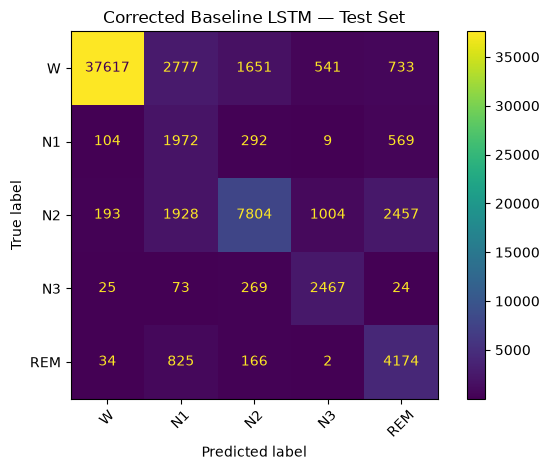

In [20]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_test_pred,
)

print("Confusion matrix:")
print(cm)

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names,
)

cm_display.plot(
    xticks_rotation=45,
)

plt.title(
    "Corrected Baseline LSTM — Test Set"
)

plt.tight_layout()
plt.show()